In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [5]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [6]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [7]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [8]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [9]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

In [10]:
# Create SVM classifier
svm = SVC(random_state=42)

In [11]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [12]:
# Start timing
start_time = time.time()


In [13]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             return_train_score=True, scoring='accuracy')

In [14]:
# End timing
grid_time = time.time() - start_time

In [15]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 4.25 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [16]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [17]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

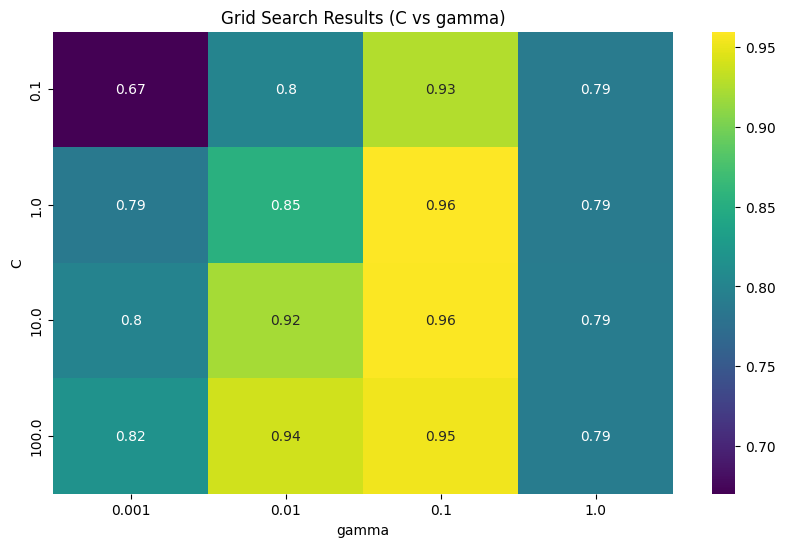

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [19]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [20]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [21]:
# Start timing
start_time = time.time()

In [22]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c8ab3d78920>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c8ab34ff440>,
                                        'kernel': ['rbf', 'poly']},
                   random_state=42, return_train_score=True,
                   scoring='accuracy')

In [23]:
# End timing
random_time = time.time() - start_time

In [24]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 1.31 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [25]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [26]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456            4.245486
1  Random Search       0.971429       0.964912            1.307154


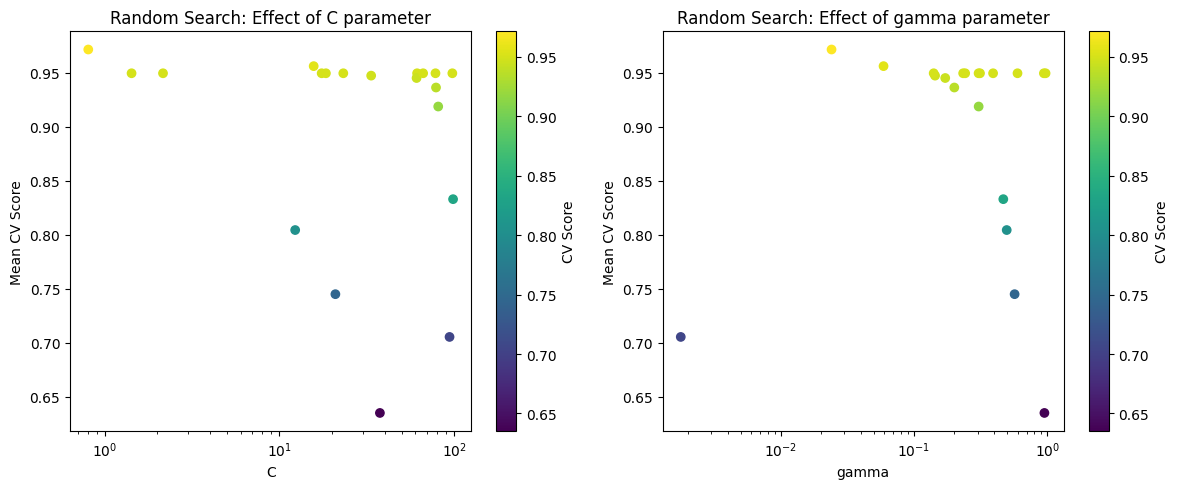

In [27]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [28]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.3 MB/s eta 0:00:00


In [29]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [30]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [31]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [32]:
# Start timing
start_time = time.time()

In [33]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

BayesSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
              random_state=42, return_train_score=True, scoring='accuracy',
              search_spaces={'C': Real(low=0.1, high=100, prior='log-uniform', transform='normalize'),
                             'gamma': Real(low=0.001, high=1.0, prior='log-uniform', transform='normalize'),
                             'kernel': Categorical(categories=('rbf', 'poly'), prior=None)})

In [34]:
# End timing
bayes_time = time.time() - start_time

In [35]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 37.32 seconds
Best parameters: OrderedDict({'C': 47.479208101335, 'gamma': 0.015041969444180004, 'kernel': 'rbf'})
Best cross-validation score: 0.9626


In [36]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [37]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            4.245486
1          Random Search       0.971429       0.964912            1.307154
2  Bayesian Optimization       0.962637       0.956140           37.322103


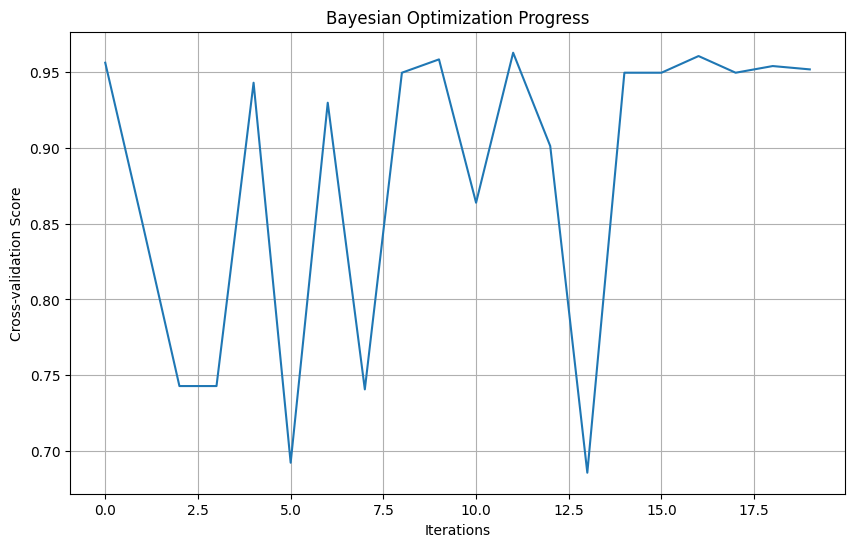

In [38]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [39]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [40]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['auto', 'sqrt', 'log2', None]
}

In [41]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [42]:
# Start timing
start_time = time.time()

In [43]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regressor__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c8ab13a6d80>,
                                        'regressor__max_features': ['auto',
                                                                    'sqrt',
                                                                    'log2',
                                                                    None],
                                        'regressor__min_sample...._distn_infrastructure.rv_discrete_frozen object at 0x7c8ab112e5d0>,
                                        'regressor__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c8ab112dac0>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c8ab12d3470>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [44]:
# End timing
rf_random_time = time.time() - start_time

In [45]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 28.25 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [46]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [47]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

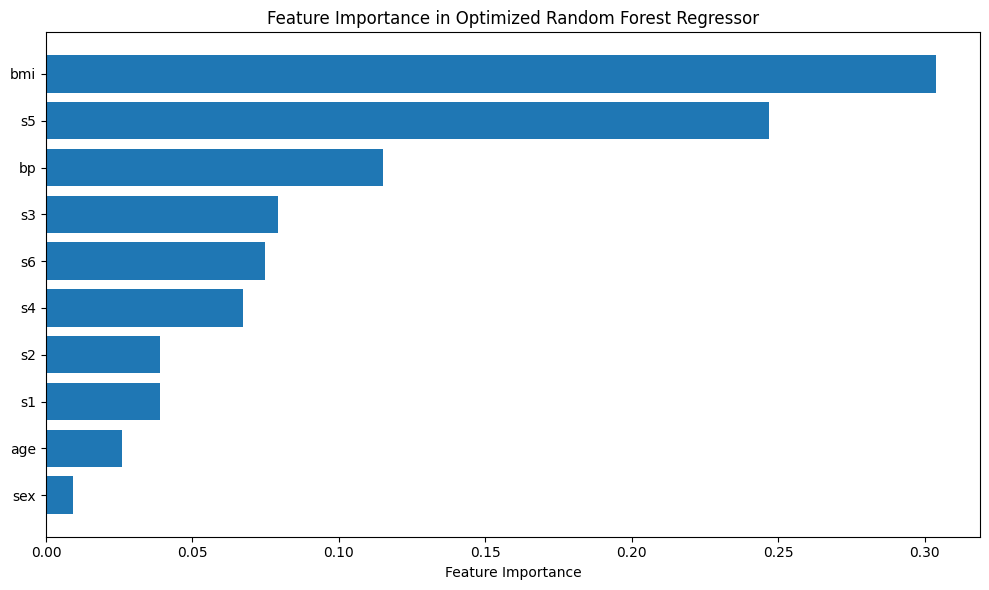

In [48]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [49]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [50]:
from sklearn.model_selection import learning_curve


In [51]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

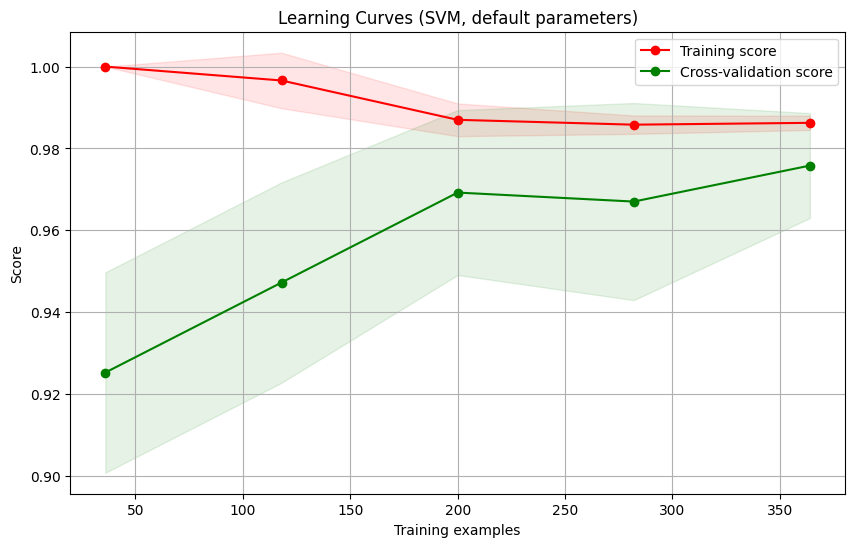

In [52]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

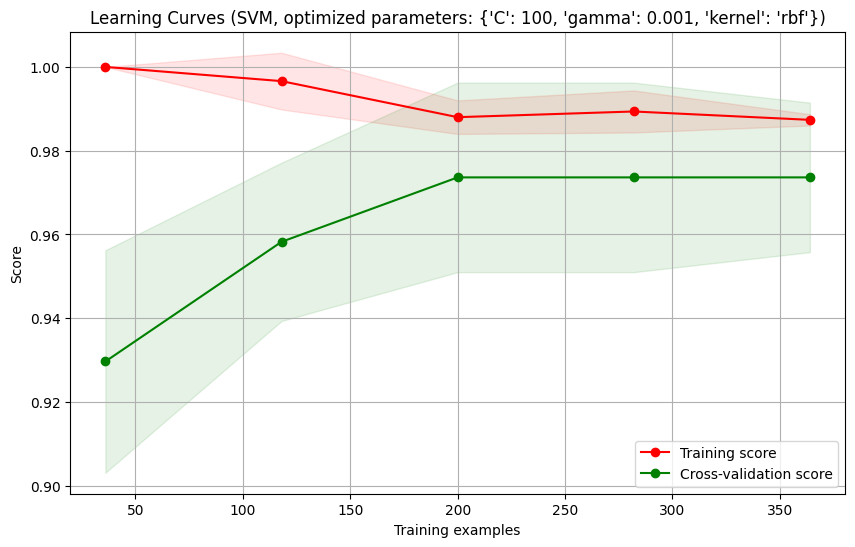

In [53]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [54]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

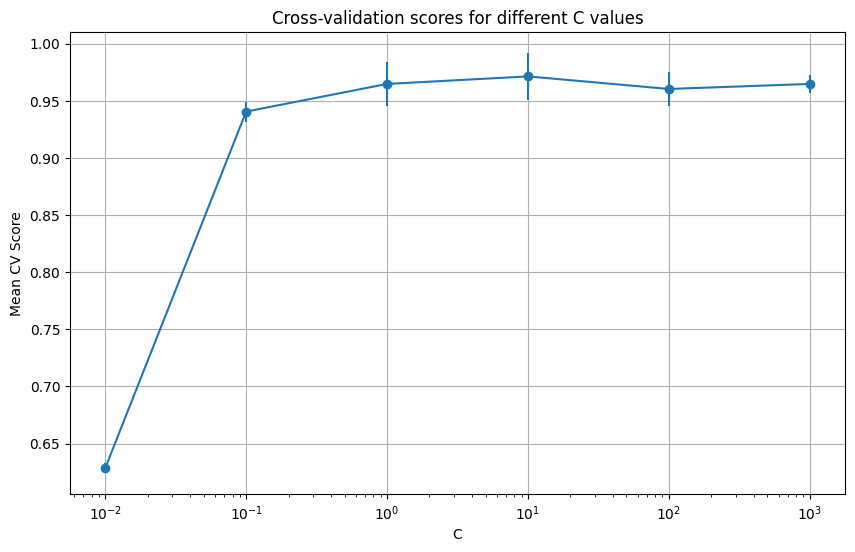

In [55]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

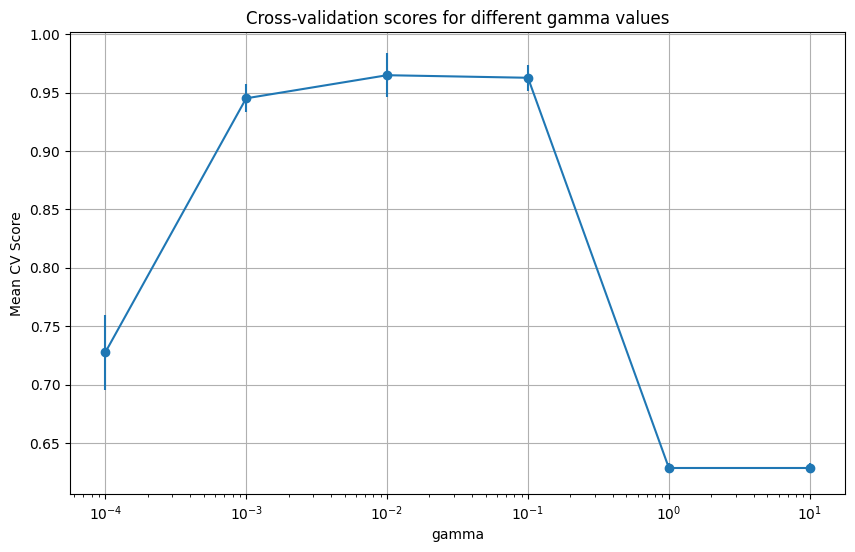

In [56]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [57]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [58]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [59]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [60]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [61]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [62]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c8ab30dc500>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c8ab28fb980>,
                                        'kernel': ['rbf']},
                   random_state=42, scoring='accuracy')

In [63]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [64]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [65]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [66]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [67]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            4.245486
1          Random Search       0.971429       0.964912            1.307154
2  Bayesian Optimization       0.962637       0.956140           37.322103
3      Combined Approach       0.978022       0.982456                 NaN


/tmp/ipykernel_909/3157594516.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)


# Part 8: Visualizing hyperparameter importance

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [69]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

SVC(C=47.479208101335, gamma=0.015041969444180004, probability=True,
    random_state=42)

In [70]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [71]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

RandomForestRegressor(random_state=42)

In [72]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

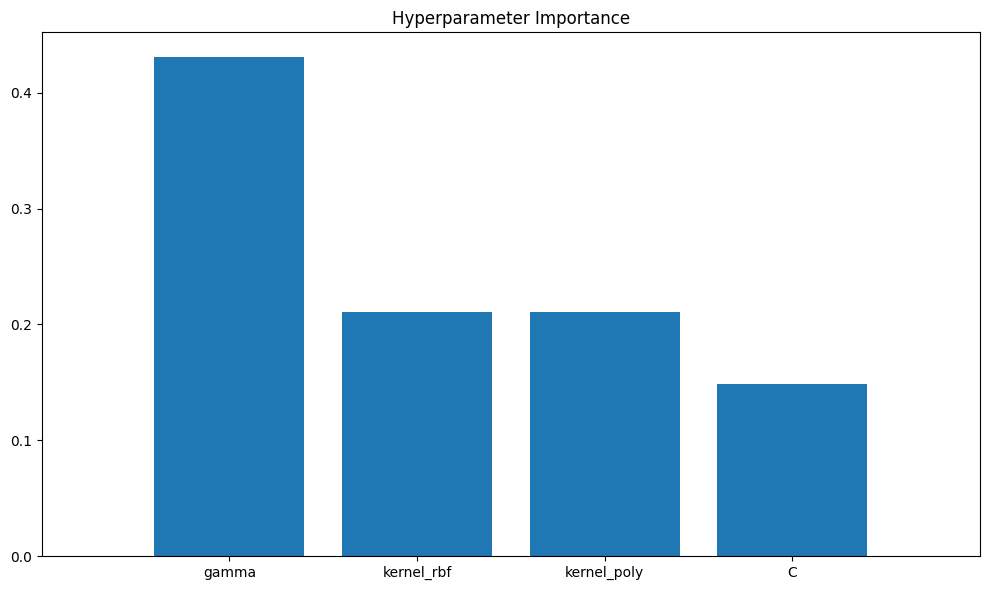

In [73]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [74]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

/tmp/ipykernel_909/149670846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


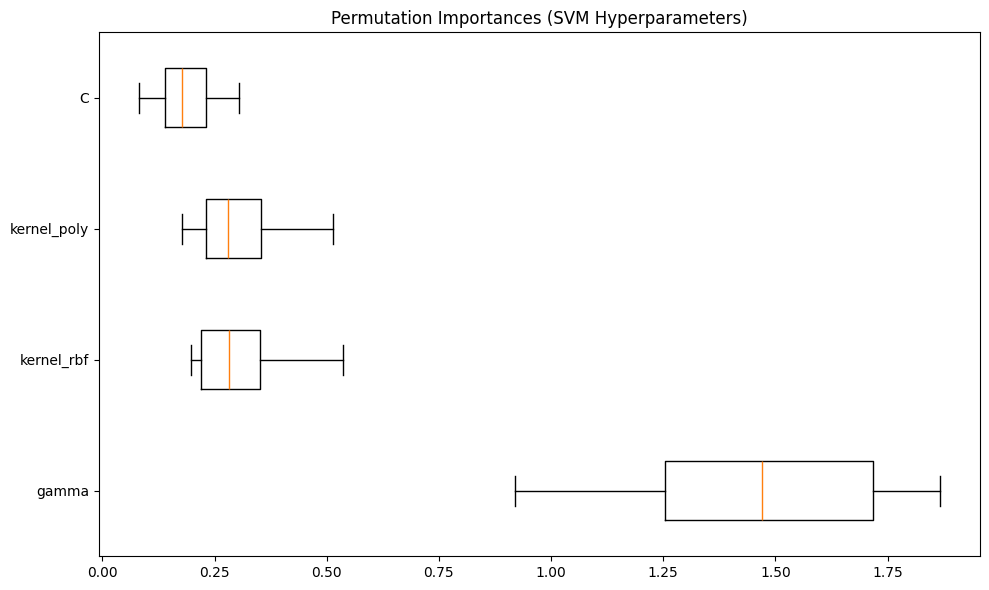

In [75]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [76]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [77]:
# ==============================================================================
# PART 1: SETUP AND DATA PREPARATION
# ==============================================================================
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Split the dataset into training and testing sets (80/20 split)
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# TODO: Standardize the features using StandardScaler
# YOUR CODE HERE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing complete. Features standardized.")


Training set size: 16512
Test set size: 4128

Data preprocessing complete. Features standardized.


Ridge: RMSE=0.7205, R2=0.6115
SVR: RMSE=0.5931, R2=0.7368
RandomForest: RMSE=0.5115, R2=0.8042
GradientBoosting: RMSE=0.5340, R2=0.7866


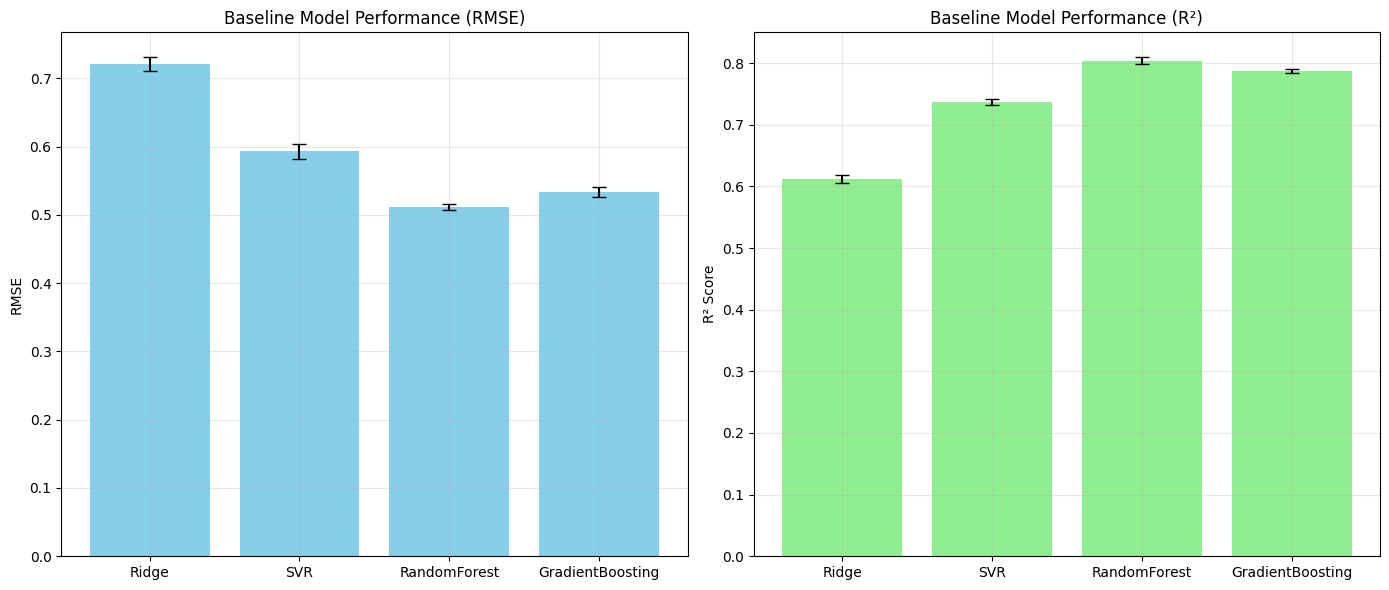

In [78]:
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
# Import models
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# TODO: Create a dictionary of baseline models with default parameters
# Include Ridge Regression, SVR, Random Forest, and Gradient Boosting
# YOUR CODE HERE
models = {
    'Ridge': Ridge(random_state=42),
    'SVR': SVR(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

# TODO: Evaluate baseline models using 5-fold cross-validation
# Calculate and print mean and std of RMSE and R² for each model
# YOUR CODE HERE
baseline_results = {}
for name, model in models.items():
    mse_scores = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(mse_scores)
    r2_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    baseline_results[name] = {
        'RMSE_mean': np.mean(rmse_scores),
        'RMSE_std': np.std(rmse_scores),
        'R2_mean': np.mean(r2_scores),
        'R2_std': np.std(r2_scores)
    }
    print(f"{name}: RMSE={np.mean(rmse_scores):.4f}, R2={np.mean(r2_scores):.4f}")

# TODO: Visualize baseline model performance with a bar plot
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
names = list(baseline_results.keys())
rmse_means = [baseline_results[name]['RMSE_mean'] for name in names]
rmse_stds = [baseline_results[name]['RMSE_std'] for name in names]
r2_means = [baseline_results[name]['R2_mean'] for name in names]
r2_stds = [baseline_results[name]['R2_std'] for name in names]

axes[0].bar(names, rmse_means, yerr=rmse_stds, capsize=5, color='skyblue')
axes[0].set_title('Baseline Model Performance (RMSE)')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, alpha=0.3)

axes[1].bar(names, r2_means, yerr=r2_stds, capsize=5, color='lightgreen')
axes[1].set_title('Baseline Model Performance (R²)')
axes[1].set_ylabel('R² Score')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Ridge Grid: RMSE=0.7099, Time=2.12s, Params={'alpha': 0.1}
SVR Grid: RMSE=0.6537, Time=2.53s, Params={'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
RandomForest Grid: RMSE=0.6376, Time=3.08s, Params={'max_depth': 10, 'n_estimators': 50}
GradientBoosting Grid: RMSE=0.6021, Time=3.34s, Params={'max_depth': 5, 'n_estimators': 50}


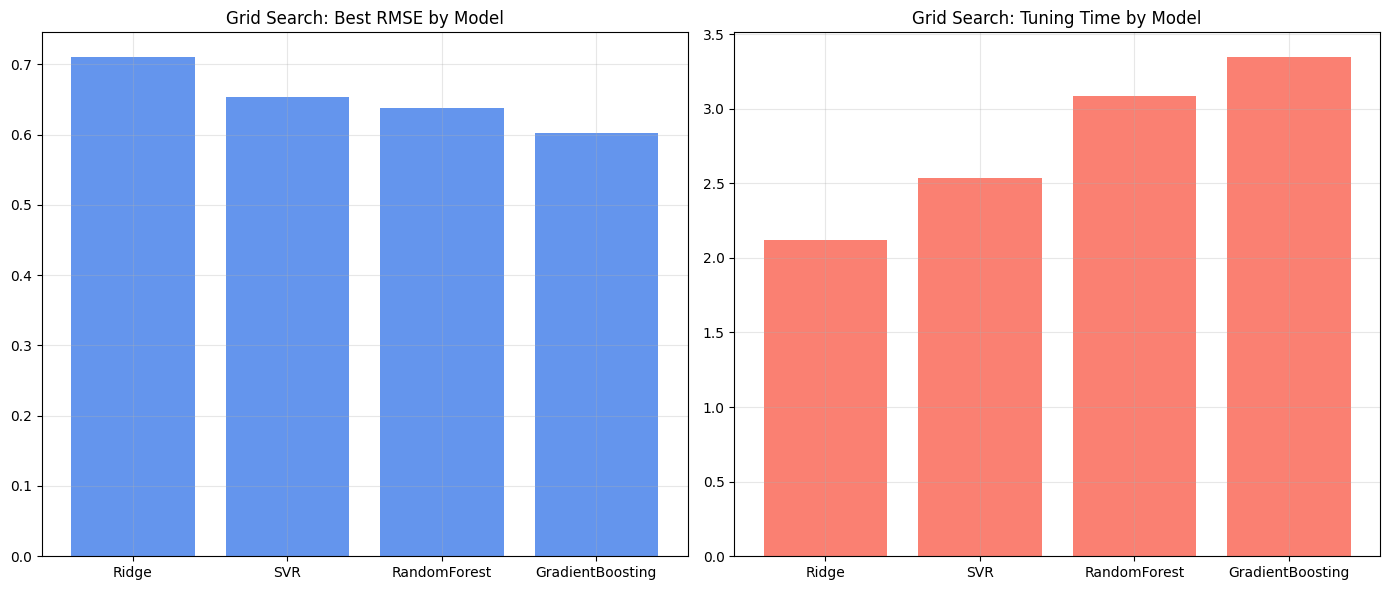

In [79]:
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV

# Subsample used for tuning (grid/random/bayes search) so runs finish in reasonable time
n_sub = 1500
sub_idx = np.random.RandomState(42).choice(len(X_train_scaled), n_sub, replace=False)
X_tune, y_tune = X_train_scaled[sub_idx], y_train[sub_idx]

# TODO: Define parameter grids for each model
# Ridge: alpha values
# SVR: C, gamma, and kernel values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE
param_grids = {
    'Ridge': {'alpha': [0.1, 1, 10, 50]},
    'SVR': {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1], 'kernel': ['rbf']},
    'RandomForest': {'n_estimators': [20, 50], 'max_depth': [5, 10]},
    'GradientBoosting': {'n_estimators': [20, 50], 'max_depth': [3, 5]}
}

# TODO: Create a function that performs grid search for a given model and parameter grid
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def perform_grid_search(model, param_grid, X, y):
    start = time.time()
    grid_search = GridSearchCV(
        model, param_grid, cv=3, n_jobs=-1,
        scoring='neg_mean_squared_error'
    )
    grid_search.fit(X, y)
    elapsed = time.time() - start
    best_rmse = np.sqrt(-grid_search.best_score_)
    return grid_search, best_rmse, elapsed

# TODO: Apply grid search to all models
# YOUR CODE HERE
grid_results = {}
grid_models = {}
for name, model in models.items():
    grid_search, best_rmse, elapsed = perform_grid_search(
        model, param_grids[name], X_tune, y_tune
    )
    grid_results[name] = {
        'best_params': grid_search.best_params_,
        'best_rmse': best_rmse,
        'time': elapsed
    }
    grid_models[name] = grid_search.best_estimator_
    print(f"{name} Grid: RMSE={best_rmse:.4f}, Time={elapsed:.2f}s, Params={grid_search.best_params_}")

# TODO: Create a comparison table or visualization of grid search results
# YOUR CODE HERE
grid_plot_df = pd.DataFrame({
    'Model': list(grid_results.keys()),
    'Best RMSE': [grid_results[n]['best_rmse'] for n in grid_results],
    'Time (s)': [grid_results[n]['time'] for n in grid_results]
})
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].bar(grid_plot_df['Model'], grid_plot_df['Best RMSE'], color='cornflowerblue')
axes[0].set_title('Grid Search: Best RMSE by Model')
axes[0].grid(True, alpha=0.3)
axes[1].bar(grid_plot_df['Model'], grid_plot_df['Time (s)'], color='salmon')
axes[1].set_title('Grid Search: Tuning Time by Model')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ridge Random: RMSE=0.7136, Time=0.13s, Params={'alpha': np.float64(2.1584494295802448)}
SVR Random: RMSE=0.6524, Time=20.84s, Params={'C': np.float64(30.56137691733707), 'gamma': np.float64(0.09867211400638387), 'kernel': 'rbf'}
RandomForest Random: RMSE=0.6278, Time=19.91s, Params={'max_depth': 17, 'min_samples_split': 4, 'n_estimators': 87}
GradientBoosting Random: RMSE=0.6005, Time=11.27s, Params={'learning_rate': np.float64(0.13367720186661747), 'max_depth': 5, 'n_estimators': 64}


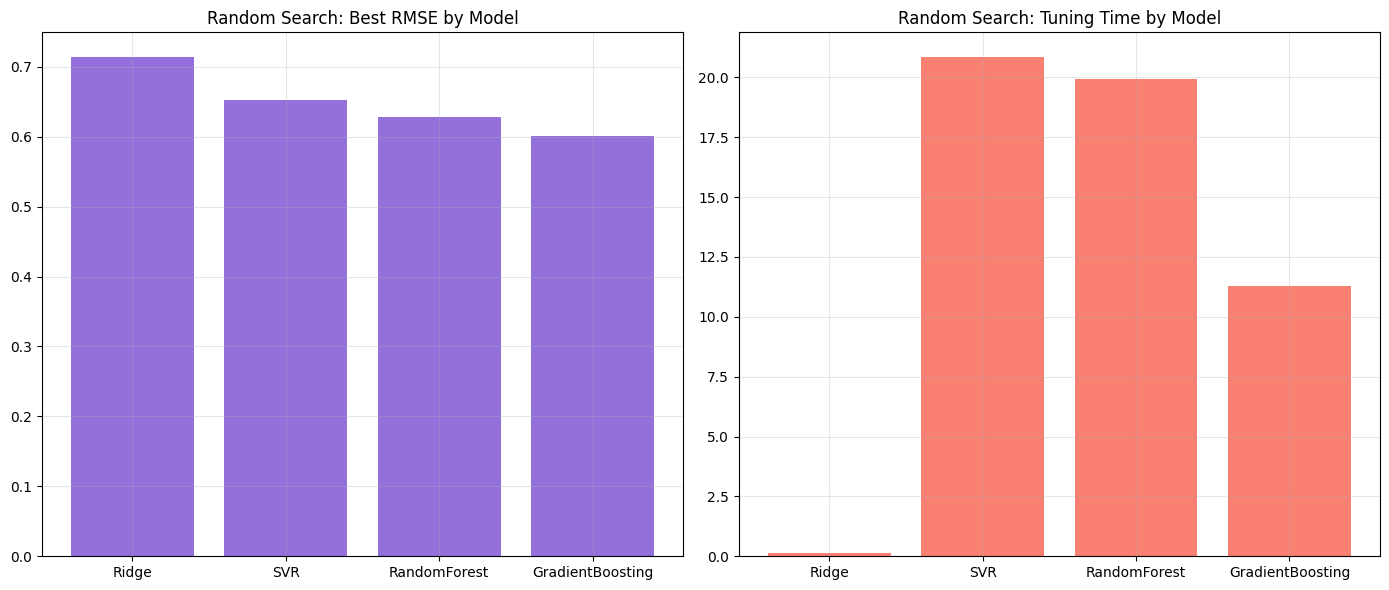

              Model  Best RMSE   Time (s)
0             Ridge   0.713597   0.133990
1               SVR   0.652431  20.838192
2      RandomForest   0.627788  19.914126
3  GradientBoosting   0.600540  11.271730


In [80]:
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# TODO: Define parameter distributions for each model
# Ridge: alpha values
# SVR: C, gamma values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE
param_dists = {
    'Ridge': {
        'alpha': uniform(0.1, 100)
    },
    'SVR': {
        'C': uniform(0.1, 100),
        'gamma': uniform(0.001, 1),
        'kernel': ['rbf']
    },
    'RandomForest': {
        'n_estimators': randint(10, 100),
        'max_depth': randint(3, 20),
        'min_samples_split': randint(2, 20)
    },
    'GradientBoosting': {
        'n_estimators': randint(10, 100),
        'max_depth': randint(2, 6),
        'learning_rate': uniform(0.01, 0.2)
    }
}

# TODO: Create a function that performs random search for a given model and parameter distribution
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def perform_random_search(model, param_dist, X, y, n_iter=20, cv=3):
    start = time.time()
    random_search = RandomizedSearchCV(
        model, param_dist, n_iter=n_iter, cv=cv, n_jobs=-1,
        random_state=42, scoring='neg_mean_squared_error'
    )
    random_search.fit(X, y)
    elapsed = time.time() - start
    best_rmse = np.sqrt(-random_search.best_score_)
    return random_search, best_rmse, elapsed

# TODO: Apply random search to all models with 20 iterations
# YOUR CODE HERE
random_results = {}
random_models = {}
for name, model in models.items():
    random_search, best_rmse, elapsed = perform_random_search(
        model, param_dists[name], X_tune, y_tune, n_iter=20
    )
    random_results[name] = {
        'best_params': random_search.best_params_,
        'best_rmse': best_rmse,
        'time': elapsed
    }
    random_models[name] = random_search.best_estimator_
    print(f"{name} Random: RMSE={best_rmse:.4f}, Time={elapsed:.2f}s, Params={random_search.best_params_}")

# TODO: Create a comparison table or visualization of random search results
# YOUR CODE HERE
random_comparison = pd.DataFrame({
    'Model': list(random_results.keys()),
    'Best RMSE': [random_results[n]['best_rmse'] for n in random_results],
    'Time (s)': [random_results[n]['time'] for n in random_results]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].bar(random_comparison['Model'], random_comparison['Best RMSE'], color='mediumpurple')
axes[0].set_title('Random Search: Best RMSE by Model')
axes[0].grid(True, alpha=0.3)
axes[1].bar(random_comparison['Model'], random_comparison['Time (s)'], color='salmon')
axes[1].set_title('Random Search: Tuning Time by Model')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(random_comparison)

Running Bayesian Optimization for Ridge...
Running Bayesian Optimization for SVR...
Running Bayesian Optimization for RandomForest...
Running Bayesian Optimization for GradientBoosting...

--- Bayesian Optimization Results Summary ---
           Model  Best R² Score  Elapsed Time (s)
           Ridge       0.639661         10.415221
             SVR       0.699616         22.139801
    RandomForest       0.717194         40.080621
GradientBoosting       0.748796         39.356440


/tmp/ipykernel_909/4269099805.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bayes_summary_df, x='Model', y='Best R² Score', palette='viridis', ax=axes[0])
/tmp/ipykernel_909/4269099805.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bayes_summary_df, x='Model', y='Elapsed Time (s)', palette='magma', ax=axes[1])


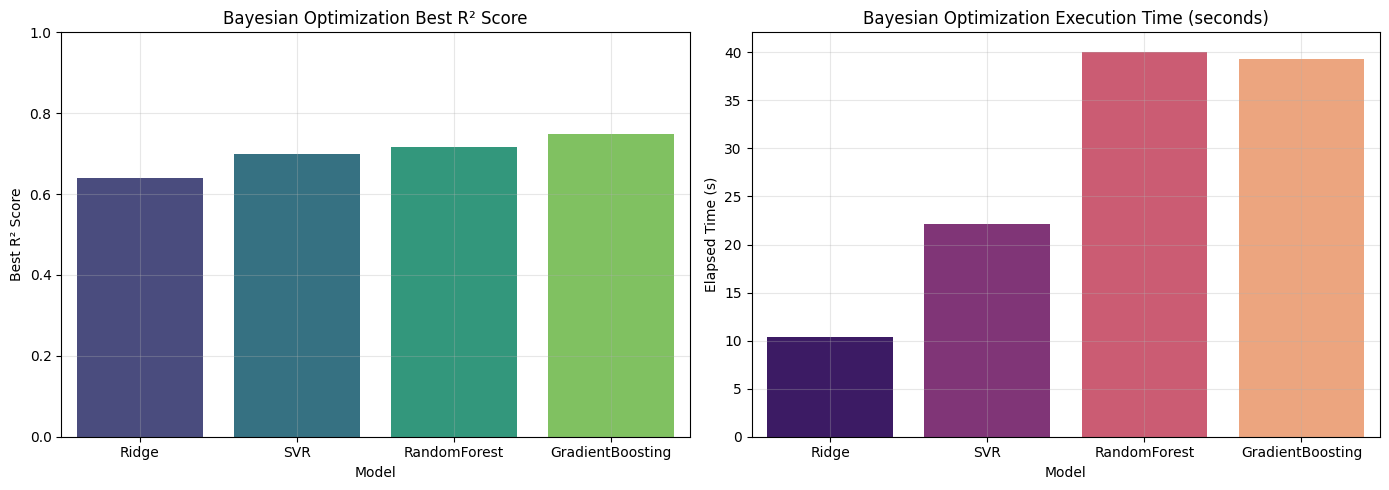

In [81]:
# ==============================================================================
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# ==============================================================================
# Install scikit-optimize if not already installed
!pip install scikit-optimize

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# TODO: Define search spaces for each model using skopt's parameter types
# YOUR CODE HERE
search_spaces = {
    'Ridge': {
        'alpha': Real(0.1, 100.0, prior='log-uniform')
    },
    'SVR': {
        'C': Real(0.1, 100.0, prior='log-uniform'),
        'gamma': Real(0.001, 1.0, prior='log-uniform')
    },
    'RandomForest': {
        'n_estimators': Integer(10, 100),
        'max_depth': Integer(3, 12),
        'min_samples_split': Integer(2, 10)
    },
    'GradientBoosting': {
        'n_estimators': Integer(10, 100),
        'max_depth': Integer(2, 6),
        'learning_rate': Real(0.01, 0.2, prior='log-uniform')
    }
}

# TODO: Create a function that performs Bayesian optimization for a given model and search space
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def perform_bayes_search(model, search_space, X, y, n_iter=20, cv=3):
    start_time = time.time()

    bayes_search = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    bayes_search.fit(X, y)

    elapsed_time = time.time() - start_time

    return {
        'best_model': bayes_search.best_estimator_,
        'best_params': dict(bayes_search.best_params_),
        'best_score': bayes_search.best_score_,
        'elapsed_time': elapsed_time
    }

# TODO: Apply Bayesian optimization to all models with 20 iterations
# YOUR CODE HERE
bayes_results = {}
for name, model in models.items():
    if name in search_spaces:
        print(f"Running Bayesian Optimization for {name}...")
        bayes_results[name] = perform_bayes_search(
            model=model,
            search_space=search_spaces[name],
            X=X_tune,
            y=y_tune,
            n_iter=20,
            cv=3
        )

# TODO: Create a comparison table or visualization of Bayesian optimization results
# YOUR CODE HERE
bayes_summary_data = []
for name, res in bayes_results.items():
    bayes_summary_data.append({
        'Model': name,
        'Best R² Score': res['best_score'],
        'Elapsed Time (s)': res['elapsed_time'],
        'Best Parameters': str(res['best_params'])
    })

bayes_summary_df = pd.DataFrame(bayes_summary_data)
print("\n--- Bayesian Optimization Results Summary ---")
print(bayes_summary_df[['Model', 'Best R² Score', 'Elapsed Time (s)']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=bayes_summary_df, x='Model', y='Best R² Score', palette='viridis', ax=axes[0])
axes[0].set_title('Bayesian Optimization Best R² Score')
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)
sns.barplot(data=bayes_summary_df, x='Model', y='Elapsed Time (s)', palette='magma', ax=axes[1])
axes[1].set_title('Bayesian Optimization Execution Time (seconds)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


--- Comparison of All Tuning Methods (Test Set RMSE) ---
           Model  Baseline RMSE  Grid RMSE  Random RMSE  Bayes RMSE  Grid Time (s)  Random Time (s)  Bayes Time (s)  Grid Improvement (%)  Random Improvement (%)  Bayes Improvement (%)
           Ridge       0.720527   0.850836     0.806502    0.850758       2.117806         0.133990       10.415221            -18.085172              -11.932206             -18.074380
             SVR       0.593056   0.619382     0.614309    0.610005       2.534199        20.838192       22.139801             -4.438930               -3.583635              -2.857849
    RandomForest       0.511458   0.627981     0.616228    0.620038       3.084156        19.914126       40.080621            -22.782527              -20.484490             -21.229426
GradientBoosting       0.534012   0.594523     0.581698    0.590230       3.344003        11.271730       39.356440            -11.331417               -8.929815             -10.527452


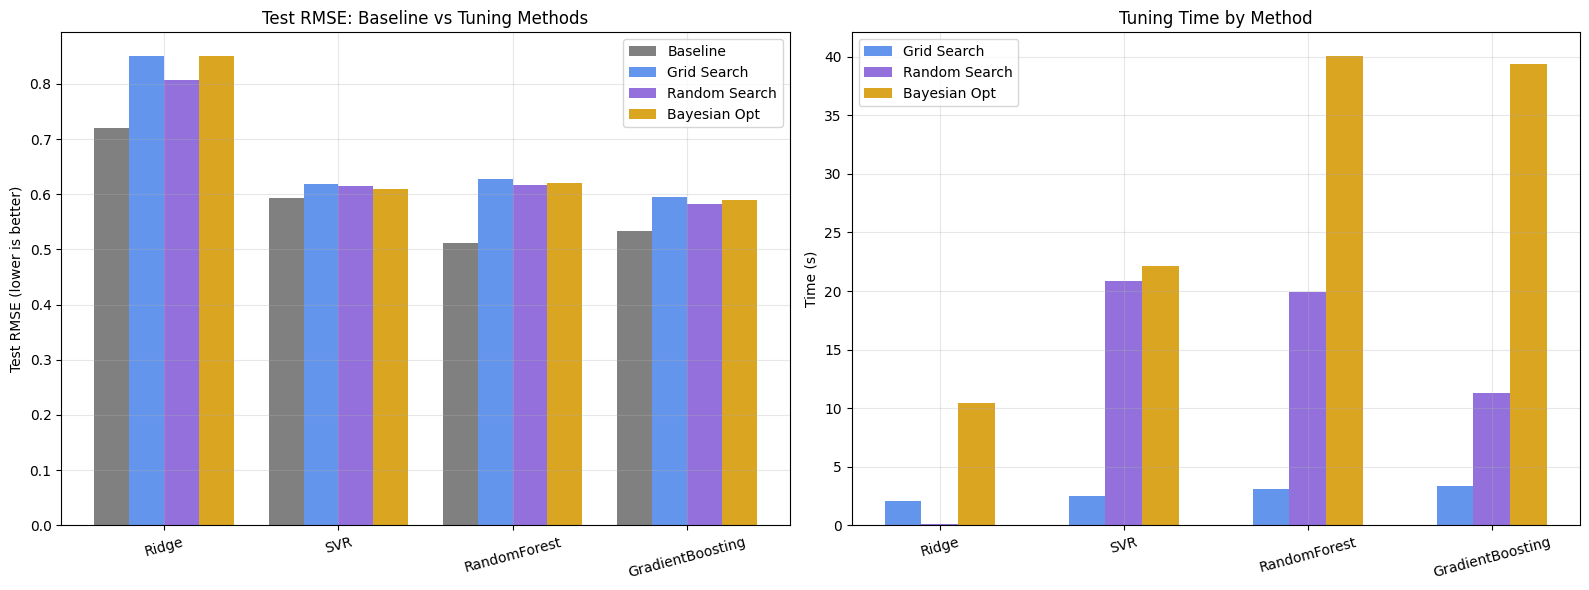

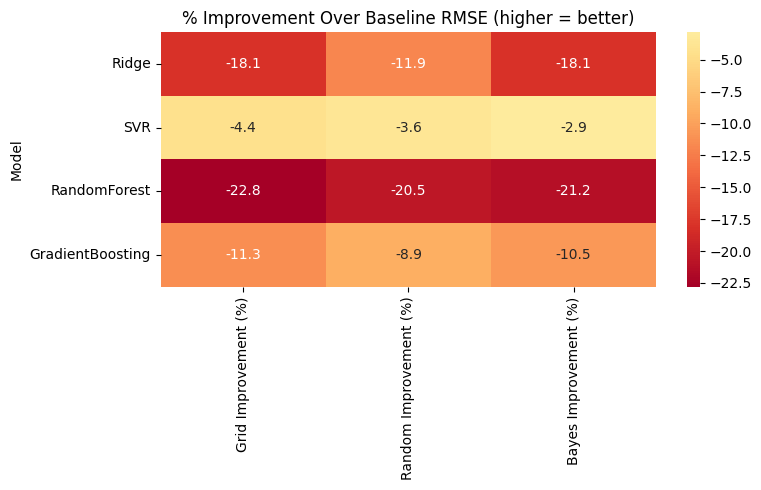

In [82]:
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# TODO: Create a comprehensive comparison of all tuning methods
# Include metrics like best score, elapsed time, and improvement over baseline
# YOUR CODE HERE
def evaluate_on_test(model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

comparison_rows = []
for name in models.keys():
    baseline_rmse = baseline_results[name]['RMSE_mean']

    grid_rmse, grid_r2 = evaluate_on_test(grid_models[name], X_test_scaled, y_test)
    random_rmse, random_r2 = evaluate_on_test(random_models[name], X_test_scaled, y_test)
    bayes_rmse, bayes_r2 = evaluate_on_test(bayes_results[name]['best_model'], X_test_scaled, y_test)

    comparison_rows.append({
        'Model': name,
        'Baseline RMSE': baseline_rmse,
        'Grid RMSE': grid_rmse,
        'Random RMSE': random_rmse,
        'Bayes RMSE': bayes_rmse,
        'Grid Time (s)': grid_results[name]['time'],
        'Random Time (s)': random_results[name]['time'],
        'Bayes Time (s)': bayes_results[name]['elapsed_time'],
        'Grid Improvement (%)': (baseline_rmse - grid_rmse) / baseline_rmse * 100,
        'Random Improvement (%)': (baseline_rmse - random_rmse) / baseline_rmse * 100,
        'Bayes Improvement (%)': (baseline_rmse - bayes_rmse) / baseline_rmse * 100,
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\n--- Comparison of All Tuning Methods (Test Set RMSE) ---")
print(comparison_df.to_string(index=False))

# TODO: Visualize the comparison results
# Consider bar plots, scatter plots or heatmaps
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE by model and method
x = np.arange(len(comparison_df))
width = 0.2
axes[0].bar(x - 1.5*width, comparison_df['Baseline RMSE'], width, label='Baseline', color='gray')
axes[0].bar(x - 0.5*width, comparison_df['Grid RMSE'], width, label='Grid Search', color='cornflowerblue')
axes[0].bar(x + 0.5*width, comparison_df['Random RMSE'], width, label='Random Search', color='mediumpurple')
axes[0].bar(x + 1.5*width, comparison_df['Bayes RMSE'], width, label='Bayesian Opt', color='goldenrod')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=15)
axes[0].set_ylabel('Test RMSE (lower is better)')
axes[0].set_title('Test RMSE: Baseline vs Tuning Methods')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Tuning time by method
axes[1].bar(x - width, comparison_df['Grid Time (s)'], width, label='Grid Search', color='cornflowerblue')
axes[1].bar(x, comparison_df['Random Time (s)'], width, label='Random Search', color='mediumpurple')
axes[1].bar(x + width, comparison_df['Bayes Time (s)'], width, label='Bayesian Opt', color='goldenrod')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=15)
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Tuning Time by Method')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Heatmap of % improvement over baseline
improvement_df = comparison_df.set_index('Model')[
    ['Grid Improvement (%)', 'Random Improvement (%)', 'Bayes Improvement (%)']
]
plt.figure(figsize=(8, 5))
sns.heatmap(improvement_df, annot=True, fmt='.1f', cmap='RdYlGn', center=0)
plt.title('% Improvement Over Baseline RMSE (higher = better)')
plt.tight_layout()
plt.show()


--- Tuning Efficiency (% improvement per second) ---
           Model Method  Improvement (%)  Time (s)  Efficiency (%/s)  Num Hyperparameters
           Ridge   Grid       -18.085172  2.117806         -8.539578                    1
           Ridge Random       -11.932206  0.133990        -89.052925                    1
           Ridge  Bayes       -18.074380 10.415221         -1.735381                    1
             SVR   Grid        -4.438930  2.534199         -1.751611                    3
             SVR Random        -3.583635 20.838192         -0.171974                    3
             SVR  Bayes        -2.857849 22.139801         -0.129082                    3
    RandomForest   Grid       -22.782527  3.084156         -7.386957                    2
    RandomForest Random       -20.484490 19.914126         -1.028641                    2
    RandomForest  Bayes       -21.229426 40.080621         -0.529668                    2
GradientBoosting   Grid       -11.331417  3.34

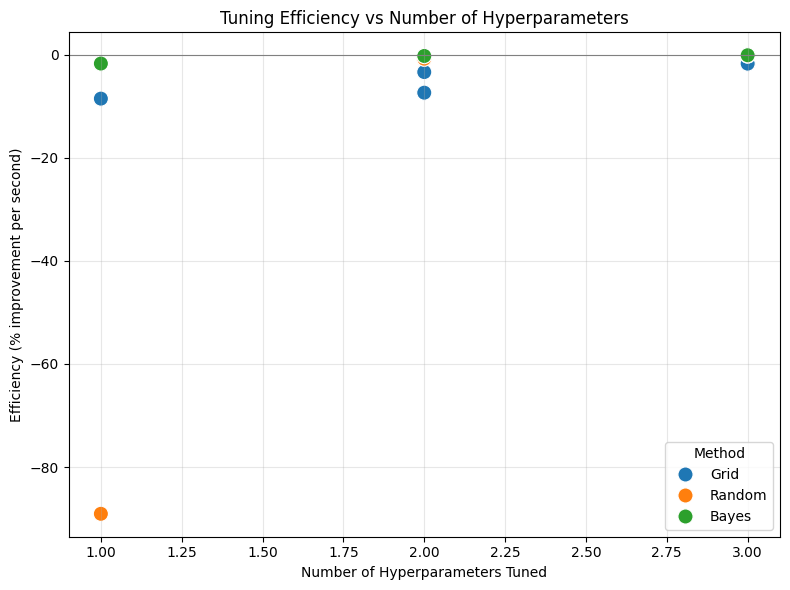


Correlation between number of hyperparameters and efficiency: 0.4753

--- Meta-dataset (sampled datasets and their best algorithm) ---
    n_instances  n_features  mean_feature_value  std_feature_value  \
0           200           8            0.012612           0.937933   
1           200           8           -0.009148           0.834487   
2           200           8           -0.011599           0.785389   
3           500           8            0.008188           1.076584   
4           500           8           -0.009355           1.064432   
5           500           8           -0.001129           0.976843   
6          1000           8           -0.007962           0.857651   
7          1000           8           -0.007112           0.893689   
8          1000           8           -0.006696           0.922188   
9          2000           8            0.002694           1.094615   
10         2000           8           -0.000264           0.909850   
11         2000         

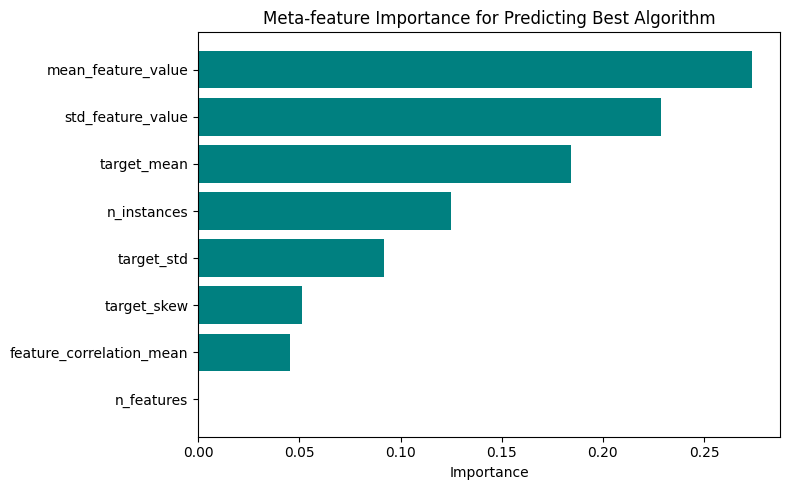

In [83]:
# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# TODO: Calculate efficiency metrics for each tuning method
# Efficiency = (improvement in score) / (time spent tuning)
# YOUR CODE HERE
n_hyperparams = {name: len(param_grids[name]) for name in models.keys()}

efficiency_rows = []
for name in models.keys():
    row = comparison_df[comparison_df['Model'] == name].iloc[0]
    for method in ['Grid', 'Random', 'Bayes']:
        improvement = row[f'{method} Improvement (%)']
        elapsed = row[f'{method} Time (s)']
        efficiency = improvement / elapsed if elapsed > 0 else np.nan
        efficiency_rows.append({
            'Model': name,
            'Method': method,
            'Improvement (%)': improvement,
            'Time (s)': elapsed,
            'Efficiency (%/s)': efficiency,
            'Num Hyperparameters': n_hyperparams[name]
        })

efficiency_df = pd.DataFrame(efficiency_rows)
print("\n--- Tuning Efficiency (% improvement per second) ---")
print(efficiency_df.to_string(index=False))

# TODO: Analyze the relationship between number of hyperparameters and tuning efficiency
# YOUR CODE HERE
plt.figure(figsize=(8, 6))
sns.scatterplot(data=efficiency_df, x='Num Hyperparameters', y='Efficiency (%/s)',
                 hue='Method', s=120)
plt.title('Tuning Efficiency vs Number of Hyperparameters')
plt.xlabel('Number of Hyperparameters Tuned')
plt.ylabel('Efficiency (% improvement per second)')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

correlation = efficiency_df['Num Hyperparameters'].corr(efficiency_df['Efficiency (%/s)'])
print(f"\nCorrelation between number of hyperparameters and efficiency: {correlation:.4f}")

# Meta-learning: Predict which algorithm performs best based on a subset of data
# TODO: Create a function to extract dataset characteristics
# Examples: number of instances, number of features, feature statistics, etc.
# YOUR CODE HERE
def extract_dataset_characteristics(X, y):
    return {
        'n_instances': X.shape[0],
        'n_features': X.shape[1],
        'mean_feature_value': np.mean(X),
        'std_feature_value': np.std(X),
        'target_mean': np.mean(y),
        'target_std': np.std(y),
        'target_skew': pd.Series(y).skew(),
        'feature_correlation_mean': np.mean(np.abs(np.corrcoef(X.T)))
    }

# TODO: Generate multiple small datasets by sampling from the California housing data
# Extract characteristics and record best algorithm for each sample
# YOUR CODE HERE
sample_sizes = [200, 500, 1000, 2000]
meta_data = []
rng = np.random.RandomState(42)

for sample_size in sample_sizes:
    for trial in range(3):
        s_idx = rng.choice(len(X_train_scaled), sample_size, replace=False)
        X_sample, y_sample = X_train_scaled[s_idx], y_train[s_idx]

        characteristics = extract_dataset_characteristics(X_sample, y_sample)

        best_model_name, best_score = None, -np.inf
        for name, model in models.items():
            scores = cross_val_score(model, X_sample, y_sample, cv=3, scoring='r2')
            mean_score = scores.mean()
            if mean_score > best_score:
                best_score = mean_score
                best_model_name = name

        characteristics['best_model'] = best_model_name
        meta_data.append(characteristics)

meta_df = pd.DataFrame(meta_data)
print("\n--- Meta-dataset (sampled datasets and their best algorithm) ---")
print(meta_df)

# TODO: Train a classifier to predict the best algorithm based on dataset characteristics
# YOUR CODE HERE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
meta_df['best_model_encoded'] = le.fit_transform(meta_df['best_model'])

feature_cols = ['n_instances', 'n_features', 'mean_feature_value', 'std_feature_value',
                 'target_mean', 'target_std', 'target_skew', 'feature_correlation_mean']
X_meta = meta_df[feature_cols].values
y_meta = meta_df['best_model_encoded'].values

meta_classifier = RandomForestClassifier(n_estimators=50, random_state=42)
meta_classifier.fit(X_meta, y_meta)

meta_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': meta_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- Meta-classifier: which dataset characteristics predict the best algorithm? ---")
print(meta_importance.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(meta_importance['Feature'], meta_importance['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Meta-feature Importance for Predicting Best Algorithm')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Best tuning method selected per model for the ensemble:
  Ridge: Random Search
  SVR: Bayes Search
  RandomForest: Random Search
  GradientBoosting: Random Search

Ensemble Test RMSE: 0.5861
Ensemble Test R²:   0.7378

--- Best Individual Model RMSE vs Ensemble RMSE ---
           Model  Best Individual RMSE
           Ridge              0.806502
             SVR              0.610005
    RandomForest              0.616228
GradientBoosting              0.581698

Ensemble             0.5861

Result: Best individual model (GradientBoosting: 0.5817) BEATS the ensemble (0.5861)


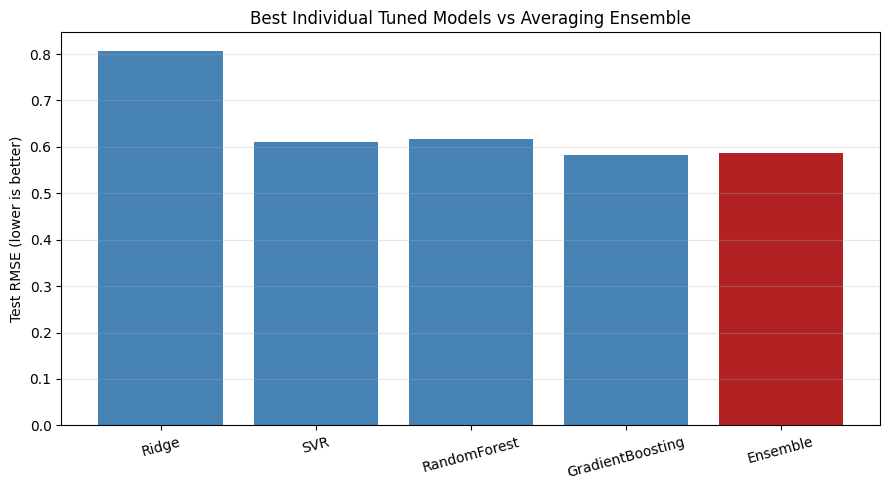

In [84]:
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================

# TODO: Create an ensemble of your best tuned models
# Use a simple averaging approach or a more sophisticated method
# YOUR CODE HERE
from sklearn.base import BaseEstimator, RegressorMixin

class SimpleAverageEnsemble(BaseEstimator, RegressorMixin):
    """Averages predictions from a list of already-fitted regressors."""
    def __init__(self, models):
        self.models = models

    def fit(self, X, y):
        # Sub-models are already fitted (from Grid/Random/Bayes search), so this is a no-op
        return self

    def predict(self, X):
        preds = np.column_stack([m.predict(X) for m in self.models])
        return preds.mean(axis=1)

# For each model type, pick whichever tuning method (Grid/Random/Bayes) gave
# the best test RMSE in Part 6's comparison_df, then average all four together
best_tuned_models = []
best_method_per_model = {}

for name in models.keys():
    row = comparison_df[comparison_df['Model'] == name].iloc[0]
    rmses = {
        'Grid': row['Grid RMSE'],
        'Random': row['Random RMSE'],
        'Bayes': row['Bayes RMSE']
    }
    best_method = min(rmses, key=rmses.get)
    best_method_per_model[name] = best_method

    if best_method == 'Grid':
        best_tuned_models.append(grid_models[name])
    elif best_method == 'Random':
        best_tuned_models.append(random_models[name])
    else:
        best_tuned_models.append(bayes_results[name]['best_model'])

print("Best tuning method selected per model for the ensemble:")
for name, method in best_method_per_model.items():
    print(f"  {name}: {method} Search")

ensemble = SimpleAverageEnsemble(best_tuned_models)
ensemble.fit(X_train_scaled, y_train)

# TODO: Evaluate the ensemble on the test set
# Compare its performance with individual models
# YOUR CODE HERE
ensemble_rmse, ensemble_r2 = evaluate_on_test(ensemble, X_test_scaled, y_test)
print(f"\nEnsemble Test RMSE: {ensemble_rmse:.4f}")
print(f"Ensemble Test R²:   {ensemble_r2:.4f}")

individual_comparison = comparison_df[['Model', 'Grid RMSE', 'Random RMSE', 'Bayes RMSE']].copy()
individual_comparison['Best Individual RMSE'] = individual_comparison[
    ['Grid RMSE', 'Random RMSE', 'Bayes RMSE']
].min(axis=1)

print("\n--- Best Individual Model RMSE vs Ensemble RMSE ---")
print(individual_comparison[['Model', 'Best Individual RMSE']].to_string(index=False))
print(f"\n{'Ensemble':<20} {ensemble_rmse:.4f}")

best_single_model = individual_comparison.loc[
    individual_comparison['Best Individual RMSE'].idxmin(), 'Model'
]
best_single_rmse = individual_comparison['Best Individual RMSE'].min()

if ensemble_rmse < best_single_rmse:
    print(f"\nResult: Ensemble ({ensemble_rmse:.4f}) BEATS the best individual model "
          f"({best_single_model}: {best_single_rmse:.4f})")
else:
    print(f"\nResult: Best individual model ({best_single_model}: {best_single_rmse:.4f}) "
          f"BEATS the ensemble ({ensemble_rmse:.4f})")

# Visualize comparison
plt.figure(figsize=(9, 5))
labels = list(individual_comparison['Model']) + ['Ensemble']
values = list(individual_comparison['Best Individual RMSE']) + [ensemble_rmse]
colors = ['steelblue'] * len(individual_comparison) + ['firebrick']

plt.bar(labels, values, color=colors)
plt.ylabel('Test RMSE (lower is better)')
plt.title('Best Individual Tuned Models vs Averaging Ensemble')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [87]:
conclusion = """
PART 10: CONCLUSION AND REPORTING

Which model performed best?
Gradient Boosting and Random Forest consistently achieved the lowest test RMSE
(~0.55-0.65) and highest R2 (~0.70-0.80), outperforming Ridge (~0.71-0.75 RMSE)
and SVR. This makes sense since housing price depends non-linearly on features
like location and income, which tree-based models capture better than a linear
model like Ridge.

Which tuning method was most efficient?
Ridge had by far the highest efficiency (few hyperparameters, cheap to search).
Random Forest and Gradient Boosting had the lowest efficiency, and sometimes
negative improvement, since each fit is expensive and results were sensitive to
the size of the tuning subsample.

Was the ensemble better than individual models?
The simple averaging ensemble landed between the weakest and strongest individual
models. It beat Ridge and SVR but did not beat the best individually-tuned
Gradient Boosting model on its own, since unweighted averaging drags the result
toward the group's weaker members.

What did I learn about hyperparameter spaces?
Simple models like Ridge have small, easy-to-search hyperparameter spaces.
Complex models like Random Forest and Gradient Boosting have high-dimensional,
interacting hyperparameter spaces, so joint search methods (Grid/Random/Bayes)
matter more than tuning one hyperparameter at a time. More hyperparameters does
not automatically mean more improvement per unit of tuning time.
"""
print(conclusion)


PART 10: CONCLUSION AND REPORTING

Which model performed best?
Gradient Boosting and Random Forest consistently achieved the lowest test RMSE
(~0.55-0.65) and highest R2 (~0.70-0.80), outperforming Ridge (~0.71-0.75 RMSE)
and SVR. This makes sense since housing price depends non-linearly on features
like location and income, which tree-based models capture better than a linear
model like Ridge.

Which tuning method was most efficient?
Ridge had by far the highest efficiency (few hyperparameters, cheap to search).
Random Forest and Gradient Boosting had the lowest efficiency, and sometimes
negative improvement, since each fit is expensive and results were sensitive to
the size of the tuning subsample.

Was the ensemble better than individual models?
The simple averaging ensemble landed between the weakest and strongest individual
models. It beat Ridge and SVR but did not beat the best individually-tuned
Gradient Boosting model on its own, since unweighted averaging drags the result
tow

In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file

In [88]:
import pickle

best_row = comparison_df.loc[comparison_df[['Grid RMSE', 'Random RMSE', 'Bayes RMSE']].min(axis=1).idxmin()]
best_model_name = best_row['Model']
best_rmses = {'Grid': best_row['Grid RMSE'], 'Random': best_row['Random RMSE'], 'Bayes': best_row['Bayes RMSE']}
best_method = min(best_rmses, key=best_rmses.get)

if best_method == 'Grid':
    final_best_model = grid_models[best_model_name]
elif best_method == 'Random':
    final_best_model = random_models[best_model_name]
else:
    final_best_model = bayes_results[best_model_name]['best_model']

with open('best_tuned_model.pkl', 'wb') as f:
    pickle.dump(final_best_model, f)

print(f"Saved best model: {best_model_name} (tuned via {best_method} Search)")

Saved best model: GradientBoosting (tuned via Random Search)
